In [1]:
from models.just_think import run_models 
from models import utils
from analysis import analysis_utils, constants
import pandas as pd 
FILE_PATH = "./"
import numpy as np
import random as random
import json 



In [2]:

# load games and game metadata
base_game_objs, idx2game, game2idx, game_stimuli = analysis_utils.process_game_stimuli(constants.THINK_STIMULI_PTH)

# example game
# 1x10 3 in a row wins.
game_descr = '1.0*10.0*3 pieces in a row wins.'
game_idx = game2idx[game_descr]
game_info = base_game_objs[game_idx-1] # includes game metadata

In [3]:
# load "just think" responses per game 

with open(f"analysis/final_processed_res/think/human_processed.json", "r") as f: 
    think_data = json.load(f)

# extract human payoff resps for that example game
human_resps = think_data['human_payoff'][game_descr]['payoff']
print('Sample of human-predicted payoffs: ', human_resps[:5])

Sample of human-predicted payoffs:  [0.09000000000000005, 0.0, 0.5031999999999999, 0.055000000000000035, 0.0]


In [4]:
# run the Intuitive Gamer ("heuristics") against itself for the game
# predict the outcomes 
# draw many simulations in aggregate
# these will be subsampled to simulate someone drawing small k (e.g., k=6)

np.random.seed(7)
random.seed(7)

output = run_models.get_model_pred(game_info, agent="heuristics", early_stop=False, 
                                   num_sims=200)
all_sims = output['game_scores'] # -1 = P2 won, 0 = draw , 1 = P1 wins


In [5]:
# bootstrapping process 
# run many simulated "expeiments"
# of simulating N participants, each drawing k game simulations

k = 6 # num sims per simulated participant
n_sim_participants = 20
n_bootstrap = 1000 # example 

simulated_exps = []
for _ in range(n_bootstrap): 
    payoff_preds = []
    for sim_participant_id in range(n_sim_participants): 
        participant_sims = np.random.choice(all_sims, size=k, replace=True)
        outcome_dist = utils.get_outcome_dist(participant_sims)
        payoff = utils.compute_utility(outcome_dist['draw'], outcome_dist['win']) # pdraw, pwin
        payoff_preds.append(payoff)
    simulated_exps.append(payoff_preds)



In [6]:
print("Sample of one Intuitive Gamer simulated of simulated predicted payoffs: ", simulated_exps[0][:5])

Sample of one Intuitive Gamer simulated of simulated predicted payoffs:  [0.16666666666666666, 0.0, 0.0, 0.0, 0.0]


Text(0.5, 0, 'Predicted Payoff')

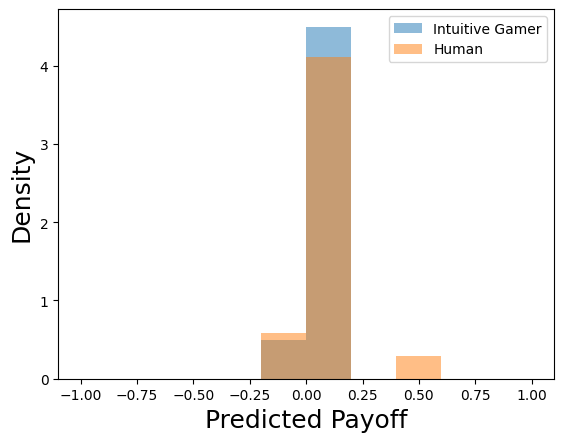

In [7]:
from matplotlib.pylab import plt 
bins = 10
xrange = [-1.0, 1.0] 
# plot for one exp
plt.hist(simulated_exps[0], density=True,
         label = 'Intuitive Gamer', 
         alpha=0.5, 
         bins=bins, range=xrange)
plt.hist(human_resps, density=True,
          alpha=0.5, 
         label='Human', bins=bins, range=xrange)
plt.ylabel("Density", fontsize=18)
plt.legend()
plt.xlabel("Predicted Payoff", fontsize=18)

In [8]:
''' 
Example loading and processing of human watch data
And extracting the corresponding play data for the watch exp
'''

with open(f"human-data/play-exp/human-v-human/final-play/final_agg.json", "r") as f: 
    human_gameplay_data = json.load(f) # 41 games 

with open("human-data/watch-exp/final_res.json", "r") as f: 
    watch_data = json.load(f) # 21 games

# rem IDs that used standard values too much [as pre-reg]
rem_ids = ['MUJ2ELF5D6', 'XAOHNXHKQL', 'FRF6G0BXYN', 'J090IDCESB', 'ZMSROEENK1', 'ZRSSZKF1VU', 'B8RXDIXOCL', 'M9SW86IBCL', '2WKOW6RBSH', 'O5CGUJIT5A']

GAME_STAGES = ['early', 'intermediate', 'late']
order2stage = {i: v for i, v in enumerate(GAME_STAGES)}

move_idx_offset = -1

PLAYED_GAME_DATA = {} 

for uid, uid_data in watch_data.items(): 
    if uid in rem_ids: continue
    for game, game_res in uid_data.items(): 
        batch_metadata = game_res['batch_metadata']
        arena = batch_metadata['arena'] 
        
        played_moves = batch_metadata['played_pos']
        
        if game not in PLAYED_GAME_DATA: PLAYED_GAME_DATA[game] = {}
        if arena not in PLAYED_GAME_DATA[game]: PLAYED_GAME_DATA[game][arena] = {}
        
        # get moves 'so far' for each board 
        boards = batch_metadata['boards']
        processed_boards = analysis_utils.process_game_states(boards)
        pred_move_idxs = batch_metadata['pred_move_idxs']
        
        # get game outcome 
        play_data = human_gameplay_data[game]
        player2order = None
        # make sure to pull out the "right" arena
        for arena2, order2player, outcome, all_move_times in zip(play_data['arena'],  
                                                 play_data["order2player"], 
                                                 play_data["outcome"],
                                                 play_data['move_times']): 
            if arena != arena2: continue
            player2order = {v: k for k,v in order2player.items()}

            if outcome == "Draw": 
                obs_outcome = 0 
            else: 
                obs_outcome = int(player2order[outcome])
                
            played_move_times = [all_move_times[idx] for idx in pred_move_idxs]
                
            break
        
        boards_at_stage = {}
        
        for order, move_idx in enumerate(pred_move_idxs): 
            stage = GAME_STAGES[order]
            boards_at_stage[stage] = processed_boards[move_idx + move_idx_offset]
            
        PLAYED_GAME_DATA[game][arena] = {
            'boards_at_stage': boards_at_stage,
            'played_pos': played_moves,
            'obs_outcome': obs_outcome,
            'move_idxs': pred_move_idxs, 
            'player2order': player2order, 
            'played_move_times': played_move_times,
            'player_at_pos': batch_metadata['player_at_idx']
            
        }
        
all_games = sorted(PLAYED_GAME_DATA.keys())

human_watch_data = {game: {} for game in all_games}
human_watch_payoffs = {game: [] for game in all_games}
human_watch_fun = {game: [] for game in all_games}

for user, user_data in watch_data.items():
    for game, game_data in user_data.items(): 
        arena = game_data['batch_metadata']['arena']
        
        if arena not in human_watch_data[game]: 
            human_watch_data[game][arena] = {game_stage: {
                'dist': [], 'rt': [], 'uid': []
                } for game_stage in GAME_STAGES}
            
        payoff = game_data['judgements'][-1]
        if payoff is not None: 
            human_watch_payoffs[game].append(payoff)
        else: 
            if 'response' in game_data['judgements'][0]: human_watch_fun[game].append(game_data['judgements'][0]['response'])
            
        for order, entry in enumerate(game_data['pred_moves']):
            raw_pred_moves, _, _, _, rt = entry
            game_stage = GAME_STAGES[order]
            
            # convert click count format of keys: 'row-col' --> (row, col)
            pred_move_dist = {}
            n_rows_game, n_cols_game, win_conds = game.split("*")
            n_rows_game = int(float(n_rows_game))
            n_cols_game = int(float(n_cols_game))
            
            for r in range(n_rows_game): 
                for c in range(n_cols_game): 
                    pred_move_dist[(r, c)] = 0
            norm_counts = int(np.sum(list(raw_pred_moves.values())))
            for k, v in raw_pred_moves.items(): 
                row, col = k.split('-')
                row = int(row)
                col = int(col)
                k = (row,col)
                pred_move_dist[k] = v / norm_counts

            human_watch_data[game][arena][game_stage]['dist'].append(pred_move_dist)
            human_watch_data[game][arena][game_stage]['rt'].append(rt)
            human_watch_data[game][arena][game_stage]['uid'].append(user)